In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# import os
# sim_path = os.path.abspath(os.path.join("..", "src", "simulation"))
# if sim_path not in sys.path:
#     sys.path.insert(0, sim_path)

In [11]:
import sys
import os
import cv2
import numpy as np
import onnxruntime as ort
import rospy
from sensor_msgs.msg import Image
from jetracer.nvidia_racecar import NvidiaRacecar

print(f"[+] ONNX Runtime Version: {ort.__version__}")

# Kiểm tra các Provider xử lý (Ưu tiên CUDA/TensorRT)
available_providers = ort.get_available_providers()
print(f"[+] Available Providers: {available_providers}")

if 'CUDAExecutionProvider' in available_providers:
    print("[✓] Đã sẵn sàng chạy ONNX trên GPU (CUDA)!")
else:
    print("[!] Cảnh báo: Không tìm thấy CUDA Provider, mô hình sẽ chạy bằng CPU.")

[+] ONNX Runtime Version: 1.10.0
[+] Available Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
[✓] Đã sẵn sàng chạy ONNX trên GPU (CUDA)!


In [12]:
import gc
import time
import cv2
import numpy as np
import rospy
from IPython.display import Image, clear_output, display

from smart_city.camera_steam import CameraStream 
from smart_city.processor import YOLOProcessor, RoadProcessor
from smart_city.traffic_fsm import TrafficFSM
from smart_city.onnx_engine import ONNXEngine
from smart_city.controller import RacecarController

# khởi tạo cam
cam = CameraStream(
    topic_name='/csi_cam_0/image_raw', width=500, height=300, record_video=False
)

# 1. Khởi tạo Engine
traffic_engine = ONNXEngine('../models/best.onnx')
road_engine = ONNXEngine('../models/best_model_mobilenet.onnx')

# 2. Khởi tạo Processor riêng biệt
traffic_processor = YOLOProcessor(img_size=(640))
road_processor = RoadProcessor(img_size=(224, 224), threshold=0.5)

print("✅ Đã nạp thành công Model ONNX và Khởi tạo Processor!")

[INFO] [1787214308.573785]: 📷 Đã Subscribe vào Topic: /csi_cam_0/image_raw
💡 ONNXEngine đang chạy trên: TensorrtExecutionProvider
💡 ONNXEngine đang chạy trên: TensorrtExecutionProvider
✅ Đã nạp thành công Model ONNX và Khởi tạo Processor!


In [ ]:
from smart_city.controller import RacecarController

car = RacecarController(base_throttle=0., max_throttle=0.4)

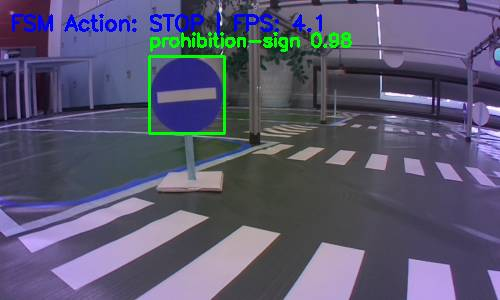

[INFO] [1787214577.667488]: 🚦 Phát hiện: prohibition-sign (0.95)
[INFO] [1787214578.212261]: 🎯 FSM State: [STOP] | FPS: 4.1 | Latency: 242.4ms
[INFO] [1787214578.225886]: 🚦 Phát hiện: prohibition-sign (0.95)
[INFO] [1787214578.779288]: 🚦 Phát hiện: prohibition-sign (0.95)
[INFO] [1787214579.323598]: 🎯 FSM State: [STOP] | FPS: 4.1 | Latency: 241.6ms
[INFO] [1787214579.337203]: 🚦 Phát hiện: prohibition-sign (0.95)
[INFO] [1787214579.881124]: 🚦 Phát hiện: prohibition-sign (0.96)
[INFO] [1787214580.445992]: 🎯 FSM State: [STOP] | FPS: 4.0 | Latency: 250.2ms
[INFO] [1787214580.459363]: 🚦 Phát hiện: prohibition-sign (0.98)
[INFO] [1787214581.006944]: 🚦 Phát hiện: prohibition-sign (0.98)
[INFO] [1787214581.566971]: 🎯 FSM State: [STOP] | FPS: 4.1 | Latency: 243.4ms
[INFO] [1787214581.586850]: 🚦 Phát hiện: prohibition-sign (0.98)
[INFO] [1787214582.130662]: 🚦 Phát hiện: prohibition-sign (0.98)
[INFO] [1787214582.677804]: 🎯 FSM State: [STOP] | FPS: 4.1 | Latency: 243.0ms
[INFO] [1787214582.693468

In [14]:
DISPLAY_UI, SKIP_FRAMES, TARGET_FPS = True, 1, 20

# ----------------------------------------------------
# 1. KHỞI TẠO STATE MACHINE NÉ VẬT CẢN (ESCAPE FSM)
# ----------------------------------------------------
CONFIRM_FRAMES = 3
CONFIRM_THRESHOLD = 0.5  # Ngưỡng xác định đường bị chặn

maneuver_state = 'DRIVE'
blocked_frame_count = 0
maneuver_start_time = time.time()

# ----------------------------------------------------
# 2. KHỞI TẠO TRAFFIC FSM & CAMERA / ROS
# ----------------------------------------------------
fsm = TrafficFSM(
    default_state='FORWARD',
    conf_threshold=0.5,
    min_consecutive_frames=3,
    state_timeout=2.0,
    min_bbox_area=900,
    roi_x_min=0.15,
    roi_x_max=0.85,
)

display_handle = display(None, display_id=True) if DISPLAY_UI else None
rate = rospy.Rate(TARGET_FPS)
frame_count = 0

rospy.loginfo("🚀 Bắt đầu Debug Stream + Escape Maneuver + Auto Control...")
# --- TRƯỚC VÒNG LẶP ---
# Tự định nghĩa các hằng số này nếu chưa có trong code của bạn
# Chiều rộng cho vùng log bên phải
LOG_PANEL_WIDTH = 350 

# Thêm một biến để theo dõi giá trị ga và lái thực tế
actual_steering = 0.0
actual_throttle = 0.0

# --- BẮT ĐẦU VÒNG LẶP WHILE ---
try:
    while not rospy.is_shutdown():
        frame = cam.get_frame()
        if frame is None:
            rospy.logwarn_throttle(2.0, "⏳ Đang chờ khung hình...")
            rate.sleep()
            continue

        start_time, frame_count = rospy.get_time(), frame_count + 1
        now = time.time()

        # --- 1. AI INFERENCE ---
        t_input, orig_h, orig_w = traffic_processor.preprocess(frame)
        detections = traffic_processor.postprocess(traffic_engine.infer(t_input), orig_h, orig_w)

        r_input = road_processor.preprocess(frame)
        road_result = road_processor.postprocess(road_engine.infer(r_input))

        road_status, blocked_prob = road_result['status'], road_result['blocked_probability']

        # --- 2. DEBOUNCE KHUNG HÌNH BỊ CHẶN ---
        if blocked_prob >= CONFIRM_THRESHOLD:
            blocked_frame_count += 1
        else:
            blocked_frame_count = max(0, blocked_frame_count - 1)

        # --- 3. STATE MACHINE NÉ VẬT CẢN & CẬP NHẬT GIÁ TRỊ LÁI/GA ---
        if maneuver_state == 'DRIVE':
            if blocked_frame_count >= CONFIRM_FRAMES:
                maneuver_state = 'REVERSE_TURNING'
                maneuver_start_time = now
                # Cập nhật giá trị sẽ hiển thị
                actual_steering = -0.7
                actual_throttle = -0.22
                # Điều khiển xe
                car.steering = actual_steering
                car.throttle = actual_throttle
            else:
                fsm_action = fsm.update(detections, img_w=orig_w, img_h=orig_h)
                # car.execute_action cần trả về giá trị steer/throttle nó đã dùng, 
                # hoặc bạn phải tự tính toán dựa trên fsm_action ở đây. 
                # Giả sử hàm car.execute_action cập nhật car.steering/car.throttle:
                car.execute_action(fsm_action)
                actual_steering = car.steering
                actual_throttle = car.throttle

        elif maneuver_state == 'REVERSE_TURNING':
            if now - maneuver_start_time < 1.2:
                actual_steering = -0.7
                actual_throttle = -0.22
            else:
                maneuver_state = 'PAUSE'
                maneuver_start_time = now
                actual_steering = 0.0
                actual_throttle = 0.0
            car.steering = actual_steering
            car.throttle = actual_throttle

        elif maneuver_state == 'PAUSE':
            if now - maneuver_start_time < 0.3:
                actual_steering = 0.0
                actual_throttle = 0.0
            else:
                maneuver_state = 'CHECK_FORWARD'
                maneuver_start_time = now
                actual_steering = 0.0
                actual_throttle = 0.15
            car.steering = actual_steering
            car.throttle = actual_throttle

        elif maneuver_state == 'CHECK_FORWARD':
            if now - maneuver_start_time < 0.8:
                actual_steering = 0.0
                actual_throttle = 0.15
            else:
                if blocked_frame_count < CONFIRM_FRAMES:
                    maneuver_state = 'DRIVE'
                    blocked_frame_count = 0
                    # Giá trị sẽ được tính ở vòng lặp sau
                else:
                    maneuver_state = 'REVERSE_TURNING'
                    maneuver_start_time = now
                    actual_steering = -0.7
                    actual_throttle = -0.22
            car.steering = actual_steering
            car.throttle = actual_throttle

        # --- 4. ROS LOGGING & METRICS ---
        latency_ms = (rospy.get_time() - start_time) * 1000
        fps_real = 1000 / max(latency_ms, 1)

        if frame_count % 50 == 0:
            clear_output(wait=True)
            if DISPLAY_UI:
                display_handle = display(None, display_id=True)

        rospy.loginfo_throttle(
            1.0, 
            f"🛣️ Road: [{road_status}] | 🔄 Maneuver: [{maneuver_state}] | ☸️ S:{actual_steering:.2f} T:{actual_throttle:.2f} | FPS: {fps_real:.1f}"
        )

        # --- 5. UI DISPLAY (PHẦN SỬA ĐỔI CHÍNH) ---
        if DISPLAY_UI and (frame_count % SKIP_FRAMES == 0):
            # 5a. Chỉ vẽ Bounding Boxes lên ảnh camera (CHỈ GIỮ LẠI PHẦN NÀY)
            debug_frame = traffic_processor.draw_bboxes(frame, detections)
            
            # --- 5b. TẠO LOG PANEL BÊN PHẢI ---
            # Tạo một hình chữ nhật đen có cùng chiều cao với ảnh camera
            h, w, c = debug_frame.shape
            log_panel = np.zeros((h, LOG_PANEL_WIDTH, c), dtype=np.uint8)
            
            # --- 5c. VIẾT LOG LÊN PANEL ---
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale = 0.5
            font_thickness = 1
            text_color = (255, 255, 255) # Màu trắng
            status_color = (0, 0, 255) if maneuver_state != 'DRIVE' else (0, 255, 0) # Đỏ nếu né, xanh nếu bình thường
            
            y_offset = 30
            line_height = 25
            
            # Tiêu đề
            cv2.putText(log_panel, "=== CAR DASHBOARD ===", (10, y_offset), font, 0.6, (0, 255, 255), 2)
            y_offset += 40
            
            # Trạng thái Maneuver (có màu)
            cv2.putText(log_panel, f"Maneuver: ", (10, y_offset), font, font_scale, text_color, font_thickness)
            cv2.putText(log_panel, f"{maneuver_state}", (110, y_offset), font, font_scale, status_color, 2)
            y_offset += line_height
            
            # Trạng thái Đường
            cv2.putText(log_panel, f"Road: {road_status} ({blocked_prob:.2f})", (10, y_offset), font, font_scale, text_color, font_thickness)
            y_offset += line_height
            
            # Phân cách
            cv2.putText(log_panel, "--- Controls ---", (10, y_offset), font, font_scale, (150, 150, 150), font_thickness)
            y_offset += line_height
            
            # GIÁ TRỊ LÁI VÀ GA (STEER/THROTTLE)
            steer_text = f"Steering: {actual_steering:.2f}"
            throttle_text = f"Throttle: {actual_throttle:.2f}"
            cv2.putText(log_panel, steer_text, (20, y_offset), font, font_scale, text_color, font_thickness)
            y_offset += line_height
            cv2.putText(log_panel, throttle_text, (20, y_offset), font, font_scale, text_color, font_thickness)
            y_offset += 40 # Khoảng cách lớn
            
            # FPS và Hiệu suất
            cv2.putText(log_panel, "--- System ---", (10, y_offset), font, font_scale, (150, 150, 150), font_thickness)
            y_offset += line_height
            cv2.putText(log_panel, f"FPS: {fps_real:.1f}", (10, y_offset), font, font_scale, text_color, font_thickness)
            y_offset += line_height
            cv2.putText(log_panel, f"Frame: {frame_count}", (10, y_offset), font, font_scale, text_color, font_thickness)
            y_offset += line_height
            cv2.putText(log_panel, f"Latency: {latency_ms:.1f} ms", (10, y_offset), font, font_scale, text_color, font_thickness)
            
            # Hiển thị Biển báo nếu có
            if len(detections) > 0:
                y_offset += 40
                cv2.putText(log_panel, "--- Detections ---", (10, y_offset), font, font_scale, (150, 150, 150), font_thickness)
                y_offset += line_height
                for i, d in enumerate(detections[:5]): # Chỉ hiển thị tối đa 5 biển báo đầu tiên
                    det_str = f"- {d['class_name']} ({d['confidence']:.2f})"
                    cv2.putText(log_panel, det_str, (10, y_offset), font, 0.4, (0, 200, 0), font_thickness)
                    y_offset += 20

            # --- 5d. GHẾP ẢNH CAMERA VÀ LOG PANEL ---
            # Ghép theo chiều ngang (hstack)
            final_display_frame = np.hstack((debug_frame, log_panel))
            
            # --- 5e. CẬP NHẬT UI ---
            rgb_frame = cv2.cvtColor(final_display_frame, cv2.COLOR_BGR2RGB)
            _, jpeg = cv2.imencode('.jpg', rgb_frame, [int(cv2.IMWRITE_JPEG_QUALITY), 70])
            display_handle.update(Image(data=jpeg.tobytes()))

        if frame_count % 100 == 0:
            gc.collect()
            
        rate.sleep()

except KeyboardInterrupt:
    car.stop()
    rospy.loginfo("🛑 Đã dừng xe do nhận KeyboardInterrupt.")
finally:
    car.stop()
    rospy.loginfo("🛑 Kết thúc chương trình, xe đã dừng an toàn.")

In [5]:
from smart_city.controller import RacecarController

controller = RacecarController()

In [7]:
controller.turn_90(direction="LEFT", speed_factor=3, forward_duration=4, reverse_duration=4)

In [25]:
controller.move_cm(10)

In [26]:
controller.turn_left(10, 1.2)

In [24]:
controller.stop()

In [20]:
controller = RacecarController(base_throttle=0.18)

# Định nghĩa các trạng thái
STATE_LANE_FOLLOWING = "LANE_FOLLOWING"
STATE_INTERSECTION = "INTERSECTION"
STATE_WAIT_RED_LIGHT = "WAIT_RED_LIGHT"

current_state = STATE_LANE_FOLLOWING

In [ ]:
try:
    while True:
        # 1. Đọc ảnh từ Camera & Dự đoán từ AI
        frame = capture_camera()
        signs = detect_traffic_signs(frame) # Trả về: ['RED_LIGHT'], ['TURN_LEFT_SIGN'], v.v.
        lane_direction = predict_lane_direction(frame) # Mô hình ONNX bám đường của bạn

        # 2. Xử lý logic Máy trạng thái (FSM)
        
        # --- TRƯỜNG HỢP 1: BẬT ĐÈN ĐỎ / BIỂN CẤM ---
        if 'RED_LIGHT' in signs or 'STOP_SIGN' in signs:
            controller.stop()
            continue

        # --- TRƯỜNG HỢP 2: PHÁT HIỆN BIỂN BÁO Ở NGÃ 3 / NGÃ 4 ---
        if 'TURN_LEFT_SIGN' in signs:
            # Đi tiến vào tâm ngã tư 20cm rồi rẽ trái
            controller.move_cm(20)
            controller.turn_left(duration=1.1)
            continue
            
        elif 'TURN_RIGHT_SIGN' in signs:
            controller.move_cm(20)
            controller.turn_right(duration=1.1)
            continue

        # --- TRƯỜNG HỢP 3: BÁM ĐƯỜNG BÌNH THƯỜNG (LANE FOLLOWING) ---
        if current_state == STATE_LANE_FOLLOWING:
            # Sử dụng kết quả dự đoán từ mô hình ONNX để chỉnh steering
            steering_angle = calculate_steering(lane_direction)
            controller.set_steering(steering_angle)
            controller.set_throttle(0.15)

except KeyboardInterrupt:
    controller.stop()
    print("Đã dừng xe an toàn.")

In [20]:
import rospy
import cv2
import numpy as np
import ipywidgets as widgets
from IPython.display import clear_output, display
from sensor_msgs.msg import Image, CompressedImage
from typing import Any, Optional

# =========================================================
# 1. HÀM DECODE ÁNH CHUẨN (KHÔNG DÙNG CV_BRIDGE)
# =========================================================

def decode_image(image_msg: Any) -> Optional[np.ndarray]:
    """Decode a ROS Image/CompressedImage message into an OpenCV BGR frame."""
    try:
        # 1. Xử lý CompressedImage (JPEG / PNG)
        if hasattr(image_msg, 'format') or 'compressed' in getattr(image_msg, 'encoding', '').lower():
            np_arr = np.frombuffer(image_msg.data, np.uint8)
            frame = cv2.imdecode(np_arr, cv2.IMREAD_COLOR)
            return frame

        # 2. Xử lý Raw Image (sensor_msgs/Image)
        encoding = image_msg.encoding.lower()
        
        # Xử lý Depth / 16-bit
        if encoding in ['16uc1', 'mono16']:
            frame = np.frombuffer(image_msg.data, dtype=np.uint16)
            frame = frame.reshape(image_msg.height, image_msg.width)
            frame = cv2.normalize(frame, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)
            frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
            return frame
        else:
            frame = np.frombuffer(image_msg.data, dtype=np.uint8)

        # Xử lý theo kênh màu
        if encoding in ['mono8', '8uc1']:
            frame = frame.reshape(image_msg.height, image_msg.width)
            frame = cv2.cvtColor(frame, cv2.COLOR_GRAY2BGR)
        elif encoding in ['bgr8', '8uc3']:
            frame = frame.reshape(image_msg.height, image_msg.width, 3)
        elif encoding in ['rgb8']:
            frame = frame.reshape(image_msg.height, image_msg.width, 3)
            frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
        elif encoding in ['bgra8', '8uc4']:
            frame = frame.reshape(image_msg.height, image_msg.width, 4)
            frame = cv2.cvtColor(frame, cv2.COLOR_BGRA2BGR)
        elif encoding in ['rgba8']:
            frame = frame.reshape(image_msg.height, image_msg.width, 4)
            frame = cv2.cvtColor(frame, cv2.COLOR_RGBA2BGR)
        else:
            frame = frame.reshape(image_msg.height, image_msg.width, -1)
            if frame.shape[2] == 4:
                frame = cv2.cvtColor(frame, cv2.COLOR_RGBA2BGR)
            elif 'rgb' in encoding:
                frame = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)

        return frame

    except Exception as e:
        return None
    
# =========================================================
# 3. POST-PROCESSING & VẼ BOUNDING BOX
# =========================================================
def draw_detections(img, outputs, conf_threshold=0.35):
    """Gia ma Tensor YOLOv8 khong can dung OpenCV NMS."""
    annotated_img = img.copy()
    h_orig, w_orig = img.shape[:2]
    
    output = outputs[0] if isinstance(outputs, list) else outputs
    output = np.squeeze(output)

    # Xoay ma tran neu shape la [84, 8400] hoac [5, 8400]
    if output.ndim == 2 and output.shape[0] < output.shape[1]:
        output = output.T

    x_factor = w_orig / 640.0
    y_factor = h_orig / 640.0

    for row in output:
        # Score cua class bien so
        score = row[4] if len(row) == 5 else np.max(row[4:])
        
        if score >= conf_threshold:
            cx, cy, w, h = row[0], row[1], row[2], row[3]
            
            # Neu mo hinh tra ve [x1, y1, x2, y2] thay vi [cx, cy, w, h]
            if cx < w and cy < h:  
                left = int((cx - 0.5 * w) * x_factor)
                top = int((cy - 0.5 * h) * y_factor)
                width = int(w * x_factor)
                height = int(h * y_factor)
            else:
                left, top = int(cx * x_factor), int(cy * y_factor)
                width, height = int((w - cx) * x_factor), int((h - cy) * y_factor)

            cv2.rectangle(annotated_img, (left, top), (left + width, top + height), (0, 0, 255), 3)
            label = f"Bien so: {score:.2f}"
            cv2.putText(annotated_img, label, (left, max(top - 10, 15)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    return annotated_img

def frame_to_bytes(frame):
    """Chuyen anh sang Byte JPEG co kiem tra an toan."""
    if frame is None or frame.size == 0:
        return None
    success, encoded_img = cv2.imencode('.jpg', frame, [int(cv2.IMWRITE_JPEG_QUALITY), 80])
    return encoded_img.tobytes() if success else None

In [21]:
# Khởi tạo ONNX Model Runner
ONNX_PATH = "../models/best_v8_opset15.onnx"
runner = ONNXModelRunner(ONNX_PATH)

# Khởi tạo ROS Node (tránh duplicate node)
try:
    rospy.init_node('notebook_onnx_node', anonymous=True, disable_signals=True)
except:
    pass

latest_frame = None

def camera_callback(msg):
    global latest_frame
    frame = decode_image(msg)
    if frame is not None:
        latest_frame = frame

# Đăng ký Subscriber
sub = rospy.Subscriber('/csi_cam_0/image_raw', Image, camera_callback, queue_size=1)
print("✅ Đã kết nối topic /csi_cam_0/image_raw thành công!")

[+] Đang nạp mô hình ONNX từ: ../models/best_v8_opset15.onnx
[✓] Nạp ONNX thành công!
 -> Input Name: images
 -> Input Shape mong đợi: [1, 3, 480, 640]
✅ Đã kết nối topic /csi_cam_0/image_raw thành công!


In [15]:
import rospy
import cv2
import numpy as np
import ipywidgets as widgets
from IPython.display import clear_output, display
from sensor_msgs.msg import Image

# 1. Khởi tạo Model ONNX Runner
ONNX_PATH = "../models/best_v8_opset15.onnx"
runner = ONNXModelRunner(ONNX_PATH)

# 2. Khởi tạo ROS Node
try:
    rospy.init_node('notebook_onnx_node', anonymous=True, disable_signals=True)
except:
    pass

latest_frame = None

def camera_callback(msg):
    global latest_frame
    try:
        img_np = np.frombuffer(msg.data, dtype=np.uint8).reshape(msg.height, msg.width, -1)
        if msg.encoding == 'rgb8':
            img_np = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)
        latest_frame = img_np
    except Exception as e:
        pass

sub = rospy.Subscriber('/csi_cam_0/image_raw', Image, camera_callback, queue_size=1)

# =========================================================
# 3. HÀM POST-PROCESSING & VẼ BOUNDING BOX (YOLOv8)
# =========================================================
def draw_detections(img, outputs, conf_threshold=0.35):
    """
    Vẽ Bounding Box cho YOLOv8 đã tích hợp sẵn End-to-End NMS.
    Output Tensor dạng: [1, N, 6] -> [x1, y1, x2, y2, confidence, class_id]
    """
    annotated_img = img.copy()
    h_orig, w_orig = img.shape[:2]
    
    # Lấy output đầu tiên và bỏ dimension batch
    output = outputs[0] if isinstance(outputs, list) else outputs
    output = np.squeeze(output)  # Dạng [N, 6]

    # Tỷ lệ scale từ 640x640 về kích thước ảnh thực tế
    x_factor = w_orig / 640.0
    y_factor = h_orig / 640.0

    for detection in output:
        # Nếu output là [x1, y1, x2, y2, score, class_id]
        score = float(detection[4])
        
        if score >= conf_threshold:
            # Lấy tọa độ x1, y1, x2, y2 trực tiếp
            x1 = int(detection[0] * x_factor)
            y1 = int(detection[1] * y_factor)
            x2 = int(detection[2] * x_factor)
            y2 = int(detection[3] * y_factor)

            # Vẽ khung hình chữ nhật
            cv2.rectangle(annotated_img, (x1, y1), (x2, y2), (0, 0, 255), 3)
            
            # In nhãn và score
            label = f"Bien so: {score:.2f}"
            cv2.putText(annotated_img, label, (x1, max(y1 - 10, 15)), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    return annotated_img

[+] Đang nạp mô hình ONNX từ: ../models/best_v8_opset15.onnx
[✓] Nạp ONNX thành công!
 -> Input Name: images
 -> Input Shape mong đợi: [1, 3, 480, 640]


In [ ]:
# Tạo ảnh placeholder mặc định
blank_frame = np.zeros((480, 640, 3), dtype=np.uint8)
cv2.putText(blank_frame, "DANG CHO TOPIC CAMERA...", (120, 240), 
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
initial_bytes = frame_to_bytes(blank_frame)

is_running = True

# Khoi tao 2 Image Widgets voi anh mac dinh
raw_widget = widgets.Image(value=initial_bytes, format='jpeg', width=500)
processed_widget = widgets.Image(value=initial_bytes, format='jpeg', width=500)

images_box = widgets.HBox([
    widgets.VBox([widgets.HTML("<b>📷 RAW CAMERA IMAGE</b>"), raw_widget]),
    widgets.VBox([widgets.HTML("<b>🎯 MODEL DETECTION OUTPUT</b>"), processed_widget])
])

stop_btn = widgets.Button(description='🛑 Dừng Inference', button_style='danger')
fps_label = widgets.HTML(value="<b>🚀 Tốc độ xử lý: <font color='orange'>Đang kết nối...</font></b>")

def on_stop_click(b):
    global is_running
    is_running = False
    stop_btn.disabled = True
    stop_btn.description = '⏹️ Đã dừng!'

stop_btn.on_click(on_stop_click)

display(stop_btn, fps_label, images_box)

prev_time = time.time()

# Vong lap chinh
try:
    while is_running and not rospy.is_shutdown():
        if latest_frame is not None:
            current_raw = latest_frame.copy()

            # 1. Inference
            input_tensor = runner.preprocess(current_raw)
            outputs = runner.infer(input_tensor)
            
            # 2. Draw Bounding Box
            result_img = draw_detections(current_raw, outputs, conf_threshold=0.35)
            
            # 3. Tinh FPS
            curr_time = time.time()
            fps = 1.0 / (curr_time - prev_time + 1e-6)
            prev_time = curr_time
            
            cv2.putText(result_img, f"FPS: {fps:.1f}", (10, 30), 
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 255), 2)

            # 4. Render Bytes
            r_bytes = frame_to_bytes(current_raw)
            p_bytes = frame_to_bytes(result_img)

            if r_bytes and p_bytes:
                raw_widget.value = r_bytes
                processed_widget.value = p_bytes
                fps_label.value = f"<b>🚀 Tốc độ xử lý: <font color='lime'>{fps:.1f} FPS</font></b>"

        rospy.sleep(0.05)

except KeyboardInterrupt:
    pass

print("🟢 Đã dừng luồng hiển thị!")

Button(button_style='danger', description='🛑 Dừng Inference', style=ButtonStyle())

HTML(value="<b>🚀 Tốc độ xử lý: <font color='orange'>Đang kết nối...</font></b>")